In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

print("All imports successful!")


All imports successful!


In [5]:
# ── Config ───────────────────────────────────────────────────
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10   # Phase 1: train new head
EPOCHS_FINETUNE = 20   # Phase 2: fine-tune deeper layers
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-4  # slightly higher than for EfficientNet

MODEL_DIR  = Path("../models")
RESULT_DIR = Path("../results")
SPLIT_DIR  = Path("../data/PlantVillage_split")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# ── Load class names & weights ───────────────────────────────
class_names   = np.load(MODEL_DIR / "class_names.npy", allow_pickle=True)
class_weights = np.load(MODEL_DIR / "class_weights.npy")
NUM_CLASSES   = len(class_names)

print(f"Number of classes: {NUM_CLASSES}")
print("Example classes:", class_names[:5])

class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}


Number of classes: 15
Example classes: ['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']


In [7]:
# ── Path sanity check ────────────────────────────────────────
print("\nChecking split folders...")
for part in ["train", "val", "test"]:
    p = SPLIT_DIR / part
    print(f"{part}: exists={p.exists()} → {p.resolve()}")



Checking split folders...
train: exists=True → C:\Users\LOQ\OneDrive\Desktop\DL-crop-disease-nepal\data\PlantVillage_split\train
val: exists=True → C:\Users\LOQ\OneDrive\Desktop\DL-crop-disease-nepal\data\PlantVillage_split\val
test: exists=True → C:\Users\LOQ\OneDrive\Desktop\DL-crop-disease-nepal\data\PlantVillage_split\test


In [8]:
# ── Generators ───────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    SPLIT_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    SPLIT_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    SPLIT_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nData generators created successfully!")
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples:       {test_gen.samples}")

# Ensure class order matches saved class_names
assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices, "Class mismatch across splits!"
assert list(train_gen.class_indices.keys()) == list(class_names), \
    "Class order mismatch with class_names.npy"

print("\nClass indices:", train_gen.class_indices)


Found 14440 images belonging to 15 classes.
Found 3097 images belonging to 15 classes.
Found 3101 images belonging to 15 classes.

Data generators created successfully!
Training samples:   14440
Validation samples: 3097
Test samples:       3101

Class indices: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [9]:
# ── Build TinyVGG-style CNN ───────────────────────────────────
def build_tinyvgg(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential(name="tinyvgg_cnn")

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                            input_shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Classifier head
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

base_model = build_tinyvgg(NUM_CLASSES)
base_model.summary()

c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "tinyvgg_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,981,231 (99.11 MB)

 Trainable params: 25,981,231 (99.11 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── "Transfer learning" style: two phases ─────────────────────
# Here, we simulate transfer learning by:
# - Phase 1: train only the classifier head (top dense layers)
# - Phase 2: unfreeze some convolutional layers for fine-tuning.

# Mark all layers trainable, then freeze conv blocks for phase 1
for layer in base_model.layers[:-3]:  # last 3 layers = Flatten + Dense + Dense
    layer.trainable = False

print("\nTrainable layers in Phase 1:")
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "trainable:", layer.trainable)


Trainable layers in Phase 1:
0 conv2d trainable: False
1 conv2d_1 trainable: False
2 max_pooling2d trainable: False
3 dropout trainable: False
4 conv2d_2 trainable: False
5 conv2d_3 trainable: False
6 max_pooling2d_1 trainable: False
7 dropout_1 trainable: False
8 conv2d_4 trainable: False
9 conv2d_5 trainable: False
10 max_pooling2d_2 trainable: False
11 dropout_2 trainable: False
12 flatten trainable: False
13 dense trainable: True
14 dropout_3 trainable: True
15 dense_1 trainable: True


In [11]:
# ── Phase 1: train head ───────────────────────────────────────
base_model.compile(
    optimizer=Adam(learning_rate=LR_FROZEN),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cb_p1 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        MODEL_DIR / "tl_tinyvgg_phase1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger(str(RESULT_DIR / "tl_tinyvgg_phase1_log.csv"))
]

print("\n=== PHASE 1: Training classifier head ===")
history_p1 = base_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=cb_p1,
    class_weight=class_weight_dict,
    verbose=1
)
print("Phase 1 training complete!")


=== PHASE 1: Training classifier head ===
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.1353 - loss: 3.4611
Epoch 1: val_accuracy improved from None to 0.15531, saving model to ..\models\tl_tinyvgg_phase1_best.keras

Epoch 1: finished saving model to ..\models\tl_tinyvgg_phase1_best.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 185s 407ms/step - accuracy: 0.1504 - loss: 2.7791 - val_accuracy: 0.1553 - val_loss: 2.6523
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.1594 - loss: 2.5542
Epoch 2: val_accuracy improved from 0.15531 to 0.15983, saving model to ..\models\tl_tinyvgg_phase1_best.keras

Epoch 2: finished saving model to ..\models\tl_tinyvgg_phase1_best.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 158s 350ms/step - accuracy: 0.1569 - loss: 2.5587 - val_accuracy: 0.1598 - val_loss: 2.6247
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.1631 - loss: 2.5336
Epoch 3: val_accuracy improved from 0.15983 to 0.16371, saving model to ..\models\tl

In [12]:
# ── Phase 2: fine-tune conv blocks ────────────────────────────
for layer in base_model.layers:
    layer.trainable = True  # unfreeze everything for simplicity

print("\nTrainable layers in Phase 2:")
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "trainable:", layer.trainable)

base_model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cb_p2 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        MODEL_DIR / "tl_tinyvgg_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger(str(RESULT_DIR / "tl_tinyvgg_phase2_log.csv"))
]

print("\n=== PHASE 2: Fine-tuning convolutional layers ===")
history_p2 = base_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=cb_p2,
    class_weight=class_weight_dict,
    verbose=1
)
print("Phase 2 training complete!")



Trainable layers in Phase 2:
0 conv2d trainable: True
1 conv2d_1 trainable: True
2 max_pooling2d trainable: True
3 dropout trainable: True
4 conv2d_2 trainable: True
5 conv2d_3 trainable: True
6 max_pooling2d_1 trainable: True
7 dropout_1 trainable: True
8 conv2d_4 trainable: True
9 conv2d_5 trainable: True
10 max_pooling2d_2 trainable: True
11 dropout_2 trainable: True
12 flatten trainable: True
13 dense trainable: True
14 dropout_3 trainable: True
15 dense_1 trainable: True

=== PHASE 2: Fine-tuning convolutional layers ===
Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.1618 - loss: 2.5251
Epoch 1: val_accuracy improved from None to 0.16403, saving model to ..\models\tl_tinyvgg_best.keras

Epoch 1: finished saving model to ..\models\tl_tinyvgg_best.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 358s 789ms/step - accuracy: 0.1612 - loss: 2.5321 - val_accuracy: 0.1640 - val_loss: 2.5824 - learning_rate: 1.0000e-04
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accura

In [13]:
# ── Save final model ──────────────────────────────────────────
base_model.save(MODEL_DIR / "tl_tinyvgg_final.keras")
print("Saved → models/tl_tinyvgg_final.keras")


Saved → models/tl_tinyvgg_final.keras


In [14]:
# ── Combine history ──────────────────────────────────────────
combined_history = {}
for k in history_p1.history:
    p1_vals = [float(v) for v in history_p1.history[k]]
    p2_vals = [float(v) for v in history_p2.history.get(k, [])]
    combined_history[k] = p1_vals + p2_vals

with open(RESULT_DIR / "tl_tinyvgg_history.json", "w") as f:
    json.dump(combined_history, f)

print("Saved → results/tl_tinyvgg_history.json")


Saved → results/tl_tinyvgg_history.json


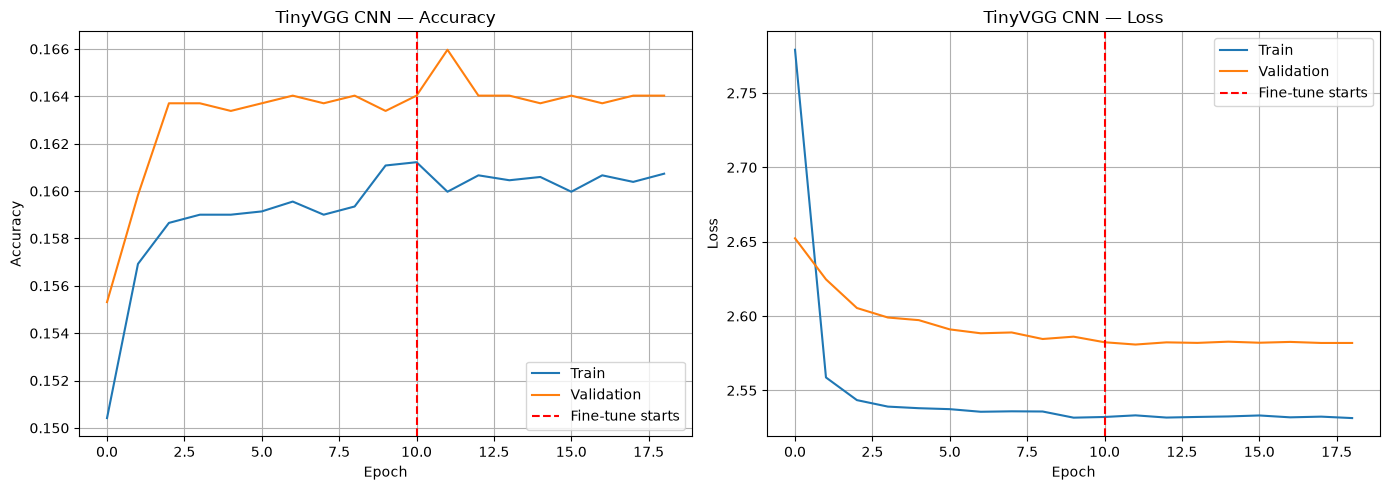

Saved → results/tl_tinyvgg_training_curves.png


In [15]:
# ── Plot curves ──────────────────────────────────────────────
total_p1 = len(history_p1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_history["accuracy"], label="Train")
axes[0].plot(combined_history["val_accuracy"], label="Validation")
axes[0].axvline(x=total_p1, color="red", linestyle="--", label="Fine-tune starts")
axes[0].set_title("TinyVGG CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(combined_history["loss"], label="Train")
axes[1].plot(combined_history["val_loss"], label="Validation")
axes[1].axvline(x=total_p1, color="red", linestyle="--", label="Fine-tune starts")
axes[1].set_title("TinyVGG CNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULT_DIR / "tl_tinyvgg_training_curves.png", dpi=150)
plt.show()

print("Saved → results/tl_tinyvgg_training_curves.png")

97/97 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.1648 - loss: 2.5816

Test results:
  loss: 2.5816
  compile_metrics: 0.1648
97/97 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       150
                     Pepper__bell___healthy       0.00      0.00      0.00       222
                      Potato___Early_blight       0.00      0.00      0.00       150
                       Potato___Late_blight       0.00      0.00      0.00       150
                           Potato___healthy       0.00      0.00      0.00        23
                      Tomato_Bacterial_spot       0.00      0.00      0.00       320
                        Tomato_Early_blight       0.00      0.00      0.00       150
                         Tomato_Late_blight       1.00      0.10      0.18       287
                           Tomato_Le

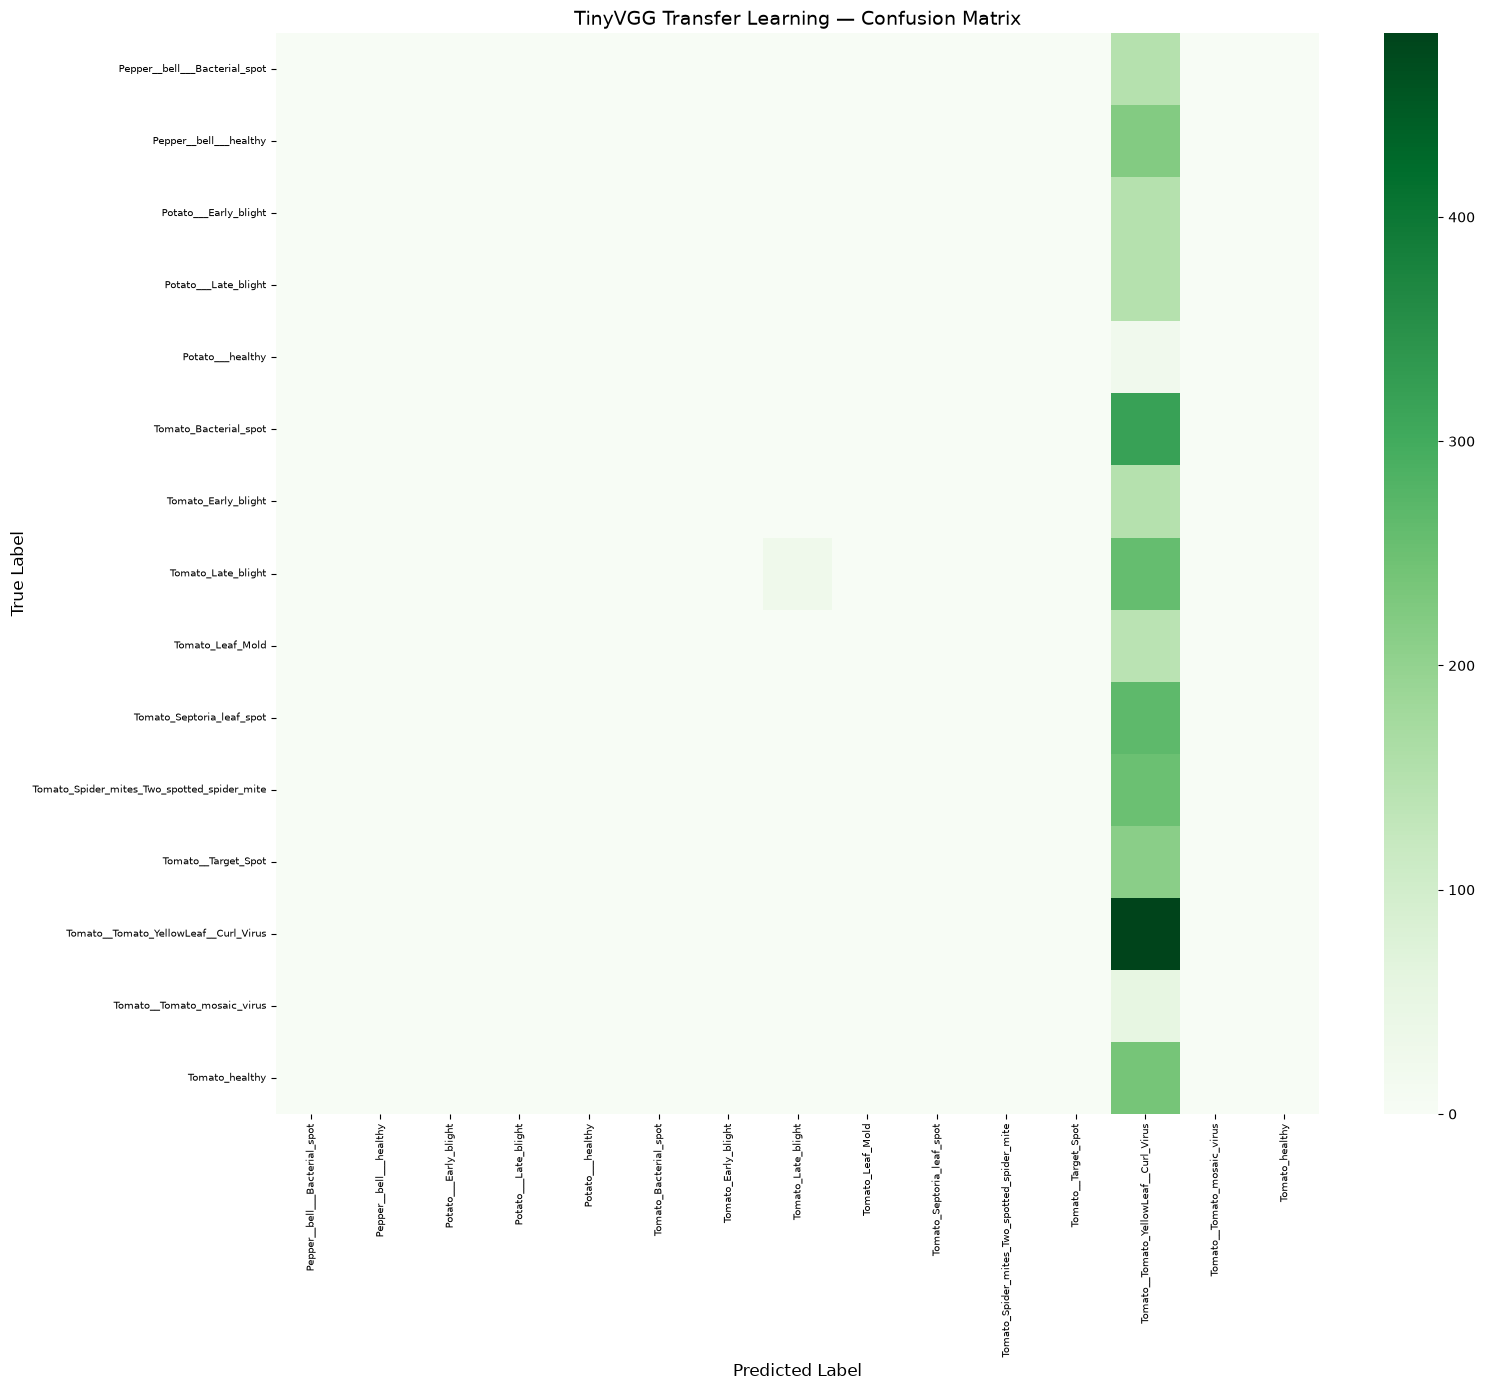

Saved → results/tl_tinyvgg_confusion_matrix.png
TinyVGG transfer learning complete


In [16]:
# ── Evaluation ───────────────────────────────────────────────
test_gen.reset()
results = base_model.evaluate(test_gen, verbose=1)
print("\nTest results:")
for name, val in zip(base_model.metrics_names, results):
    print(f"  {name}: {val:.4f}")

test_gen.reset()
pred_probs = base_model.predict(test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=False,
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("TinyVGG Transfer Learning — Confusion Matrix", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(RESULT_DIR / "tl_tinyvgg_confusion_matrix.png", dpi=150)
plt.show()

print("Saved → results/tl_tinyvgg_confusion_matrix.png")
print("TinyVGG transfer learning complete")